# stitch together ocean boundary nudging files of different sources into a one file each for salt and temp

In [2]:
import numpy as np
import pandas as pd
import xarray as xr

In [2]:
path2nudging="/expanse/lustre/scratch/jisrael/temp_project/run_schism/nudging_2026_03_03/"

In [3]:
ext1="cencoos"
ext2="hycom"

In [4]:
#salinity nc files first 
file1=xr.open_dataset(path2nudging+'SAL_nu_'+ext1+'.nc')
file2=xr.open_dataset(path2nudging+'SAL_nu_'+ext2+'.nc')
file2

<xarray.Dataset> Size: 3GB
Dimensions:               (node: 1368, time: 24000, nLevels: 23, one: 1)
Coordinates:
  * time                  (time) float32 96kB 0.0 3.6e+03 ... 8.639e+07 8.64e+07
Dimensions without coordinates: node, nLevels, one
Data variables:
    map_to_global_node    (node) int32 5kB ...
    tracer_concentration  (time, node, nLevels, one) float32 3GB ...

In [ ]:
len(file1.time)+len(file2.time)

In [5]:
# first check do the files have the same number of dimensions? Are all but time the same?
print(file1.dims)
print(len(file1.dims))
flag=0
if len(file1.dims) == len(file2.dims):
    for d in file1.dims:
        if d != 'time':
            print('Checking dimension '+d+'...')
            if d in file2.dims:
                if len(file1[d])==len(file2[d]):
                    print('This dim is good to concat!')
                else:
                    print('Dimension '+d+' is not the same size in the 2 files.')
                    flag=flag+1
            else:
                print('The two files do not have the same dimension names')
                flag=flag+1
        
else:
    print('Error: Files have different numbers of dimensions.')
    flag=flag+1


FrozenMappingWarningOnValuesAccess({'node': 1368, 'time': 3480, 'nLevels': 23, 'one': 1})
4
Checking dimension node...
This dim is good to concat!
Checking dimension nLevels...
This dim is good to concat!
Checking dimension one...
This dim is good to concat!


In [9]:
#now need to reset the time dimension of the second file
lasttime1=file1.time.values[-1]
print(lasttime1)
freq=file1.time.values[-1]-file1.time.values[-2]
print(freq)
#shift the second one so it starts one frequency unit later
new_file2 = file2.assign_coords(time=file2.time + (lasttime1 - file2.time[0] +freq))
new_file2

1.25244e+07
3600.0


<xarray.Dataset> Size: 3GB
Dimensions:               (node: 1368, time: 24000, nLevels: 23, one: 1)
Coordinates:
  * time                  (time) float32 96kB 1.253e+07 1.253e+07 ... 9.892e+07
Dimensions without coordinates: node, nLevels, one
Data variables:
    map_to_global_node    (node) int32 5kB ...
    tracer_concentration  (time, node, nLevels, one) float32 3GB ...

In [ ]:
# if flag==0:
#     file2save=xr.concat([file1,file2],dim="time")

# file2save

/scratch/jisrael/job_46990232/ipykernel_296601/3010770711.py:2: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  file2save=xr.concat([file1,file2],dim="time")


In [ ]:
# #write the file to a desired location
# writepath=path2nudging+"SAL_nu_combinded.nc"
# file2save.to_netcdf(writepath)

In [2]:
import numpy as np
import xarray as xr
def stitch_nudging(exts,path2nudging,writepath=None):
    #where exts is a vector of strings of the extensions in your files you want to splice together, e.g. ['cencoos','hycom']
    #path2nudging is the path to the directory that contains all the nudging files you want to stitch together
    #write path is the path to the directory where you want the stitched files to go
    #this will write 2 files: "SAL_nu_combined.nc" and "TEM_nu_combined.nc"
    nudgedvars=['TEM','SAL']
    if writepath==None:
        writepath=path2nudging
    for v in nudgedvars:
        "Stitching "+v+" nudging files..."
        filelist=[]
        for x in exts:
            file=xr.open_dataset(path2nudging+v+'_nu_'+x+'.nc')
            filelist.append(file)
        flag=0
        #inside var loop
        if len(set([len(f.dims) for f in filelist]))==1:
            print(v+' files have same number of dimensions!')
            for d in filelist[0].dims:
                if d != 'time':
                    print('Checking dimension '+d+'...')
                    if len(set([len(f[d]) for f in filelist]))==1:
                        print('This dim is good to concat!')
                    elif sum(np.isnan([len(f[d]) for f in filelist].isnan()))>0:
                        print("Dimension names are not all the same")
                        flag=flag+1
                    else:
                        print('Dimension '+d+' is not the same size in the 2 files.')
                        flag=flag+1
        if flag==0:
            file2save=xr.concat(filelist,dim="time")
            file2save.to_netcdf(writepath+v+"_nu_combined.nc")
                
                      

In [ ]:
path2nudging="/expanse/lustre/scratch/jisrael/temp_project/run_schism/nudging_2026_03_03/"
exts=['cencoos','hycom']
stitch_nudging(exts,path2nudging)

TEM files have same number of dimensions!
Checking dimension node...
This dim is good to concat!
Checking dimension nLevels...
This dim is good to concat!
Checking dimension one...
This dim is good to concat!


/scratch/jisrael/job_46990734/ipykernel_1646109/3840094567.py:34: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  file2save=xr.concat(filelist,dim="time")


In [3]:
exts=['cencoos','hycom']
nudgedvars=['TEM','SAL']
for v in nudgedvars:
    filelist=[]
    for x in exts:
        file=xr.open_dataset(path2nudging+v+'_nu_'+x+'.nc')
        filelist.append(file)
    flag=0
    #inside var loop
    if len(set([len(f.dims) for f in filelist]))==1:
        print('Variable '+v+' files have same num of dims!')

Variable TEM files have same num of dims!
Variable SAL files have same num of dims!


# Check the files to make sure they look okay


In [3]:
writepath="/expanse/lustre/scratch/jisrael/temp_project/run_schism/nudging_2026_04_03/"
checksal=xr.open_dataset(writepath+'SAL_nu_combined.nc')
checktem=xr.open_dataset(writepath+'TEM_nu_combined.nc')
checktem

<xarray.Dataset> Size: 1GB
Dimensions:               (time: 9960, node: 1368, nLevels: 23, one: 1)
Coordinates:
  * time                  (time) float32 40kB 0.0 3.6e+03 ... 3.585e+07
Dimensions without coordinates: node, nLevels, one
Data variables:
    map_to_global_node    (time, node) int32 55MB ...
    tracer_concentration  (time, node, nLevels, one) float32 1GB ...

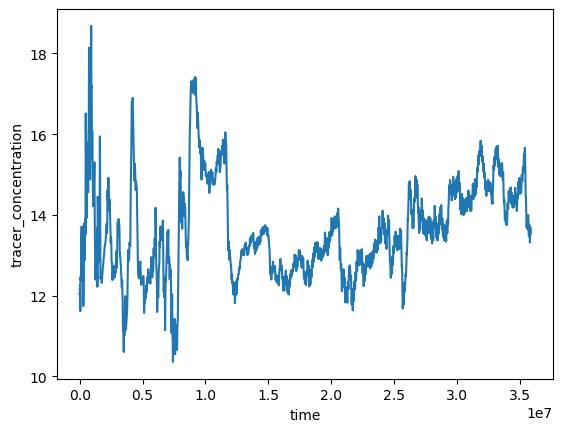

In [4]:
checktem.sel(node=1000,nLevels=0,one=0).tracer_concentration.plot()

In [4]:
if list(filelist[0].dims)==list(f.dims) for f in filelist:
    print(list(filelist[0].dims))

SyntaxError: invalid syntax (261214352.py, line 1)

In [ ]:
list(filelist[0].dims)

In [ ]:
filelist.dims

# UPDATE DO NOT need to concatenate the gr3s they do not have time history Now try the gr3s

In [ ]:
# I think need to skip the first 2 lines, add that back as a header later
header3=pd.read_csv(path2nudging+'SAL_nudge_'+ext1+'.gr3',header=None,nrows=2)
header3

In [ ]:
header3.iloc[:,0]

In [ ]:
file3=pd.read_csv(path2nudging+'SAL_nudge_'+ext1+'.gr3',skiprows=2,header=None)
file3

In [ ]:
file4=pd.read_csv(path2nudging+'SAL_nudge_'+ext2+'.gr3',skiprows=2,header=None)
file4

In [ ]:
for d in file1.dims:
    print(d)

In [ ]:
file1.node

In [ ]:
flag